# Eksperimen Machine Learning - Wine Quality Dataset
## Sony Alfauzan

---

Notebook ini merupakan tahap eksperimen awal dalam membangun sistem machine learning menggunakan dataset **Wine Quality** dari UCI Machine Learning Repository.

Tujuan utama dari eksperimen ini adalah melakukan eksplorasi data, memahami karakteristik dataset, serta mempersiapkan data agar siap digunakan untuk pelatihan model.

## 1. Perkenalan Dataset

Dataset yang digunakan dalam eksperimen ini adalah **Wine Quality Dataset** yang bersumber dari [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/wine+quality).

### Informasi Dataset
- **Sumber**: UCI Machine Learning Repository (Public Repository)
- **Pencipta**: Paulo Cortez, António Cerdeira, Fernando Almeida, Telmo Matos, José Reis
- **Jumlah Sampel**: 6.497 sampel (1.599 red wine + 4.898 white wine)
- **Jumlah Fitur**: 11 fitur input + 1 target
- **Jenis Data**: Structured / Tabular
- **Task**: Classification (kualitas wine: rendah, sedang, tinggi)

### Deskripsi Fitur
| No | Fitur | Deskripsi | Tipe |
|---|---|---|---|
| 1 | fixed acidity | Kadar asam tetap (tartaric acid) dalam g/dm³ | Numerik |
| 2 | volatile acidity | Kadar asam volatil (acetic acid) dalam g/dm³ | Numerik |
| 3 | citric acid | Kadar asam sitrat dalam g/dm³ | Numerik |
| 4 | residual sugar | Kadar gula sisa dalam g/dm³ | Numerik |
| 5 | chlorides | Kadar klorida (sodium chloride) dalam g/dm³ | Numerik |
| 6 | free sulfur dioxide | Kadar SO₂ bebas dalam mg/dm³ | Numerik |
| 7 | total sulfur dioxide | Kadar total SO₂ dalam mg/dm³ | Numerik |
| 8 | density | Densitas/kepadatan dalam g/cm³ | Numerik |
| 9 | pH | Tingkat keasaman (skala 0-14) | Numerik |
| 10 | sulphates | Kadar sulfat (potassium sulphate) dalam g/dm³ | Numerik |
| 11 | alcohol | Kadar alkohol dalam % vol | Numerik |
| 12 | quality | Skor kualitas wine (0-10) - TARGET | Numerik (Ordinal) |

### Alasan Pemilihan Dataset
1. Dataset ini memiliki variasi fitur numerik yang kaya untuk eksplorasi EDA
2. Cocok untuk tugas klasifikasi multi-kelas
3. Memerlukan preprocessing yang bermakna (handling outlier, scaling, encoding)
4. Dataset sudah well-documented dan reproducible
5. Ukuran dataset cukup untuk eksperimentasi tanpa membutuhkan resource komputasi besar

## 2. Import Library

Mengimpor seluruh library yang diperlukan untuk analisis data, visualisasi, preprocessing, dan machine learning.

In [1]:
# Data Manipulation & Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Utility
import os
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Seluruh library berhasil diimpor!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Seluruh library berhasil diimpor!
Pandas version: 2.3.3
NumPy version: 2.4.2


## 3. Memuat Dataset

Pada tahap ini, dataset Wine Quality (red & white) dimuat dan digabungkan menjadi satu DataFrame dengan penambahan kolom `wine_type` untuk membedakan jenis wine.

In [2]:
# Memuat dataset dari folder wine_quality_raw
# Dataset menggunakan delimiter semicolon (;)
raw_path = os.path.join('..', 'wine_quality_raw')

df_red = pd.read_csv(os.path.join(raw_path, 'winequality-red.csv'), sep=';')
df_white = pd.read_csv(os.path.join(raw_path, 'winequality-white.csv'), sep=';')

# Menambahkan kolom wine_type untuk identifikasi jenis wine
df_red['wine_type'] = 'red'
df_white['wine_type'] = 'white'

# Menggabungkan kedua dataset
df = pd.concat([df_red, df_white], axis=0, ignore_index=True)

print(f"Dataset Red Wine  : {df_red.shape[0]} baris, {df_red.shape[1]} kolom")
print(f"Dataset White Wine: {df_white.shape[0]} baris, {df_white.shape[1]} kolom")
print(f"Dataset Gabungan  : {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"\nTotal sampel: {len(df)}")

Dataset Red Wine  : 1599 baris, 13 kolom
Dataset White Wine: 4898 baris, 13 kolom
Dataset Gabungan  : 6497 baris, 13 kolom

Total sampel: 6497


In [3]:
# Menampilkan 5 baris pertama dataset
print("=" * 80)
print("5 BARIS PERTAMA DATASET")
print("=" * 80)
df.head()

5 BARIS PERTAMA DATASET


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [4]:
# Menampilkan 5 baris terakhir dataset
print("=" * 80)
print("5 BARIS TERAKHIR DATASET")
print("=" * 80)
df.tail()

5 BARIS TERAKHIR DATASET


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white
6496,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6,white


In [5]:
# Memeriksa informasi umum dataset
print("=" * 80)
print("INFORMASI DATASET")
print("=" * 80)
df.info()

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [6]:
# Memeriksa tipe data seluruh kolom
print("=" * 80)
print("TIPE DATA KOLOM")
print("=" * 80)
print(df.dtypes)

TIPE DATA KOLOM
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
wine_type                object
dtype: object


## 4. Exploratory Data Analysis (EDA)

Tahap EDA dilakukan untuk memahami karakteristik data secara mendalam sebelum melakukan preprocessing dan pemodelan. Analisis meliputi:
1. Statistik deskriptif
2. Analisis distribusi fitur
3. Analisis korelasi antar fitur
4. Analisis keseimbangan kelas target
5. Deteksi outlier
6. Analisis per kelompok wine_type

### 4.1 Statistik Deskriptif

In [7]:
# Statistik deskriptif untuk seluruh fitur numerik
print("=" * 80)
print("STATISTIK DESKRIPTIF")
print("=" * 80)
df.describe().T

STATISTIK DESKRIPTIF


,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [8]:
# Memeriksa missing values
print("=" * 80)
print("MISSING VALUES")
print("=" * 80)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage (%)': missing_pct
})
print(missing_info)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

MISSING VALUES
                      Missing Count  Missing Percentage (%)
fixed acidity                     0                     0.0
volatile acidity                  0                     0.0
citric acid                       0                     0.0
residual sugar                    0                     0.0
chlorides                         0                     0.0
free sulfur dioxide               0                     0.0
total sulfur dioxide              0                     0.0
density                           0                     0.0
pH                                0                     0.0
sulphates                         0                     0.0
alcohol                           0                     0.0
quality                           0                     0.0
wine_type                         0                     0.0

Total missing values: 0


In [9]:
# Memeriksa data duplikat
print("=" * 80)
print("DATA DUPLIKAT")
print("=" * 80)
duplicates = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicates}")
print(f"Persentase duplikat: {(duplicates / len(df)) * 100:.2f}%")

DATA DUPLIKAT
Jumlah baris duplikat: 1177
Persentase duplikat: 18.12%


### 4.2 Analisis Distribusi Fitur

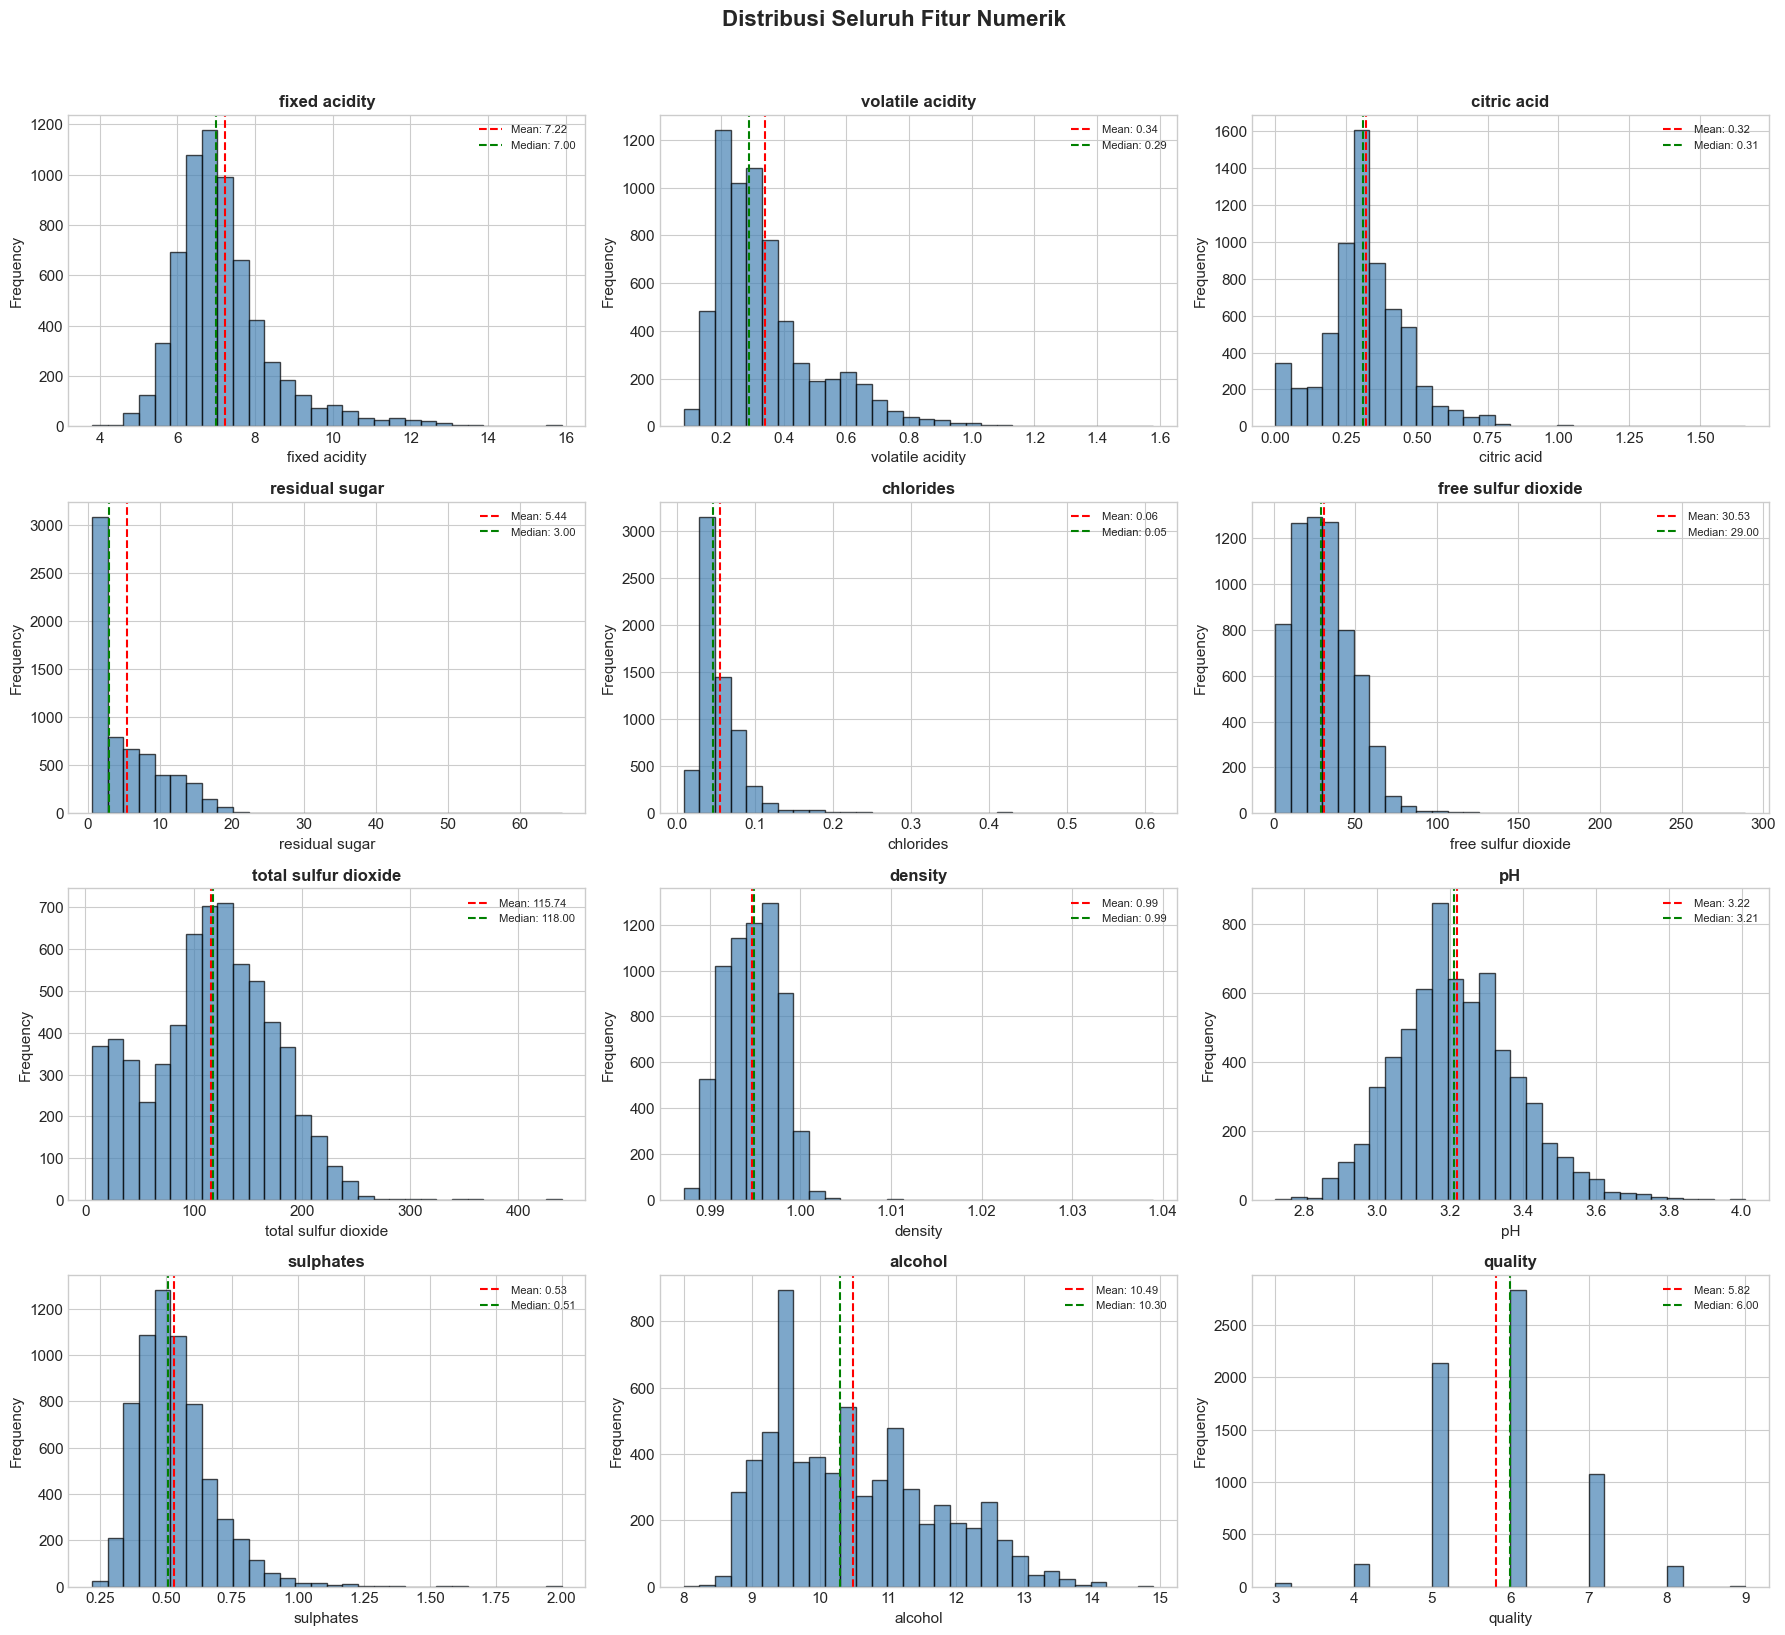

Grafik distribusi fitur berhasil disimpan.


In [10]:
# Visualisasi distribusi seluruh fitur numerik menggunakan histogram
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))
fig.suptitle('Distribusi Seluruh Fitur Numerik', fontsize=16, fontweight='bold', y=1.02)

for idx, col in enumerate(numeric_cols):
    row = idx // 3
    col_idx = idx % 3
    ax = axes[row][col_idx]
    
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='green', linestyle='--', linewidth=1.5, label=f'Median: {df[col].median():.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik distribusi fitur berhasil disimpan.")

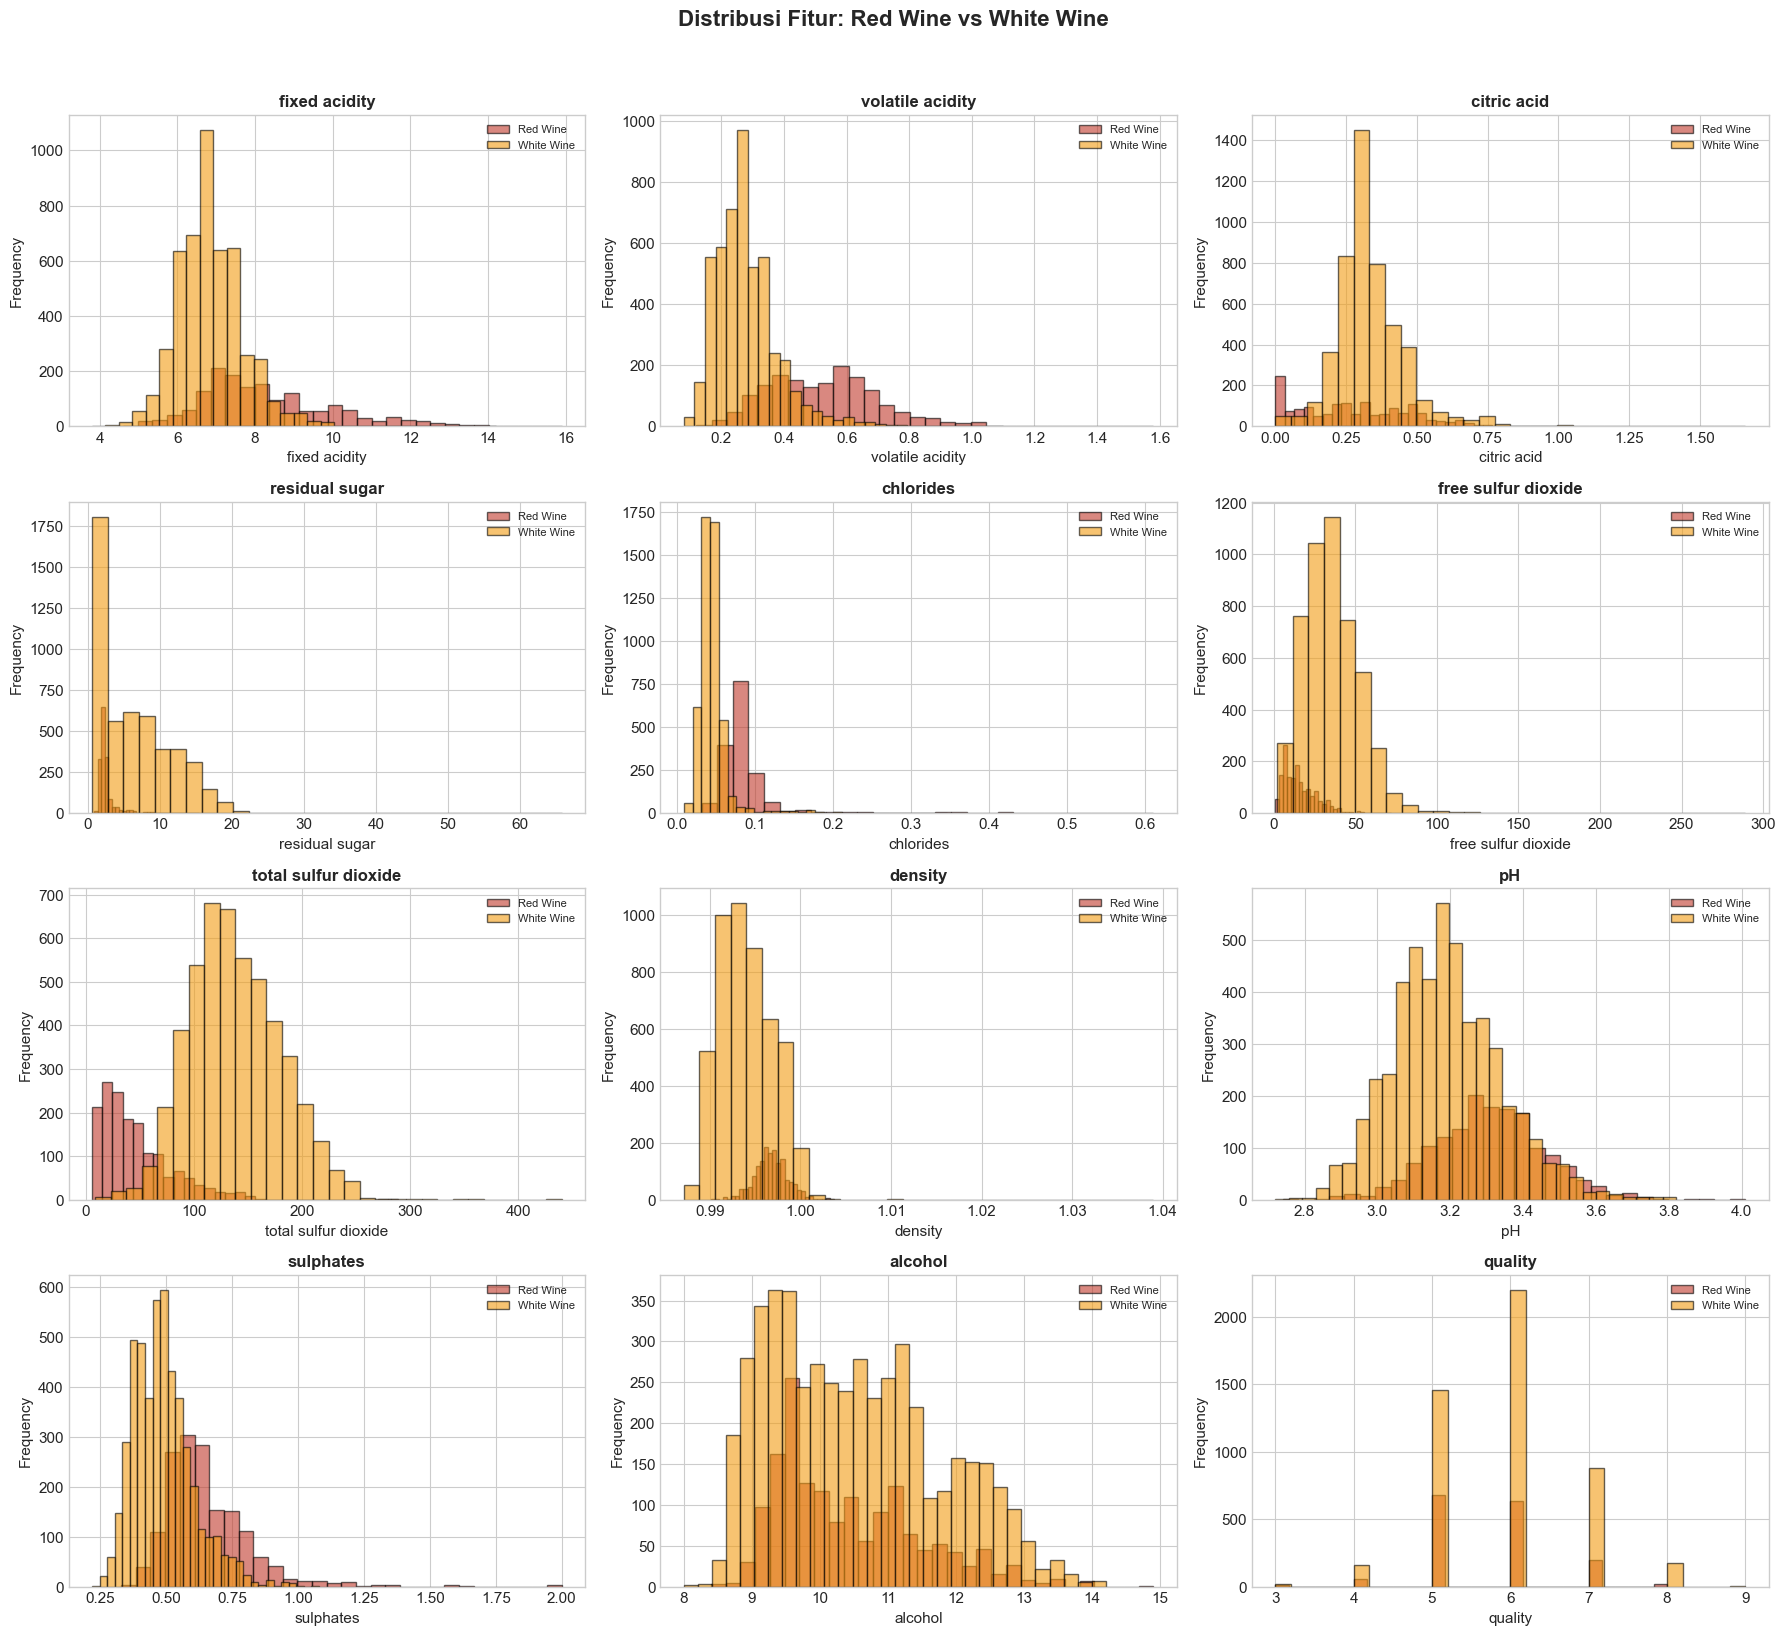

Grafik distribusi per wine type berhasil disimpan.


In [11]:
# Visualisasi distribusi fitur berdasarkan jenis wine (red vs white)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))
fig.suptitle('Distribusi Fitur: Red Wine vs White Wine', fontsize=16, fontweight='bold', y=1.02)

for idx, col in enumerate(numeric_cols):
    row = idx // 3
    col_idx = idx % 3
    ax = axes[row][col_idx]
    
    for wine_type, color in [('red', '#C0392B'), ('white', '#F39C12')]:
        subset = df[df['wine_type'] == wine_type][col]
        ax.hist(subset, bins=30, alpha=0.6, label=f'{wine_type.capitalize()} Wine', 
                color=color, edgecolor='black')
    
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('distribusi_per_wine_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik distribusi per wine type berhasil disimpan.")

### 4.3 Analisis Korelasi

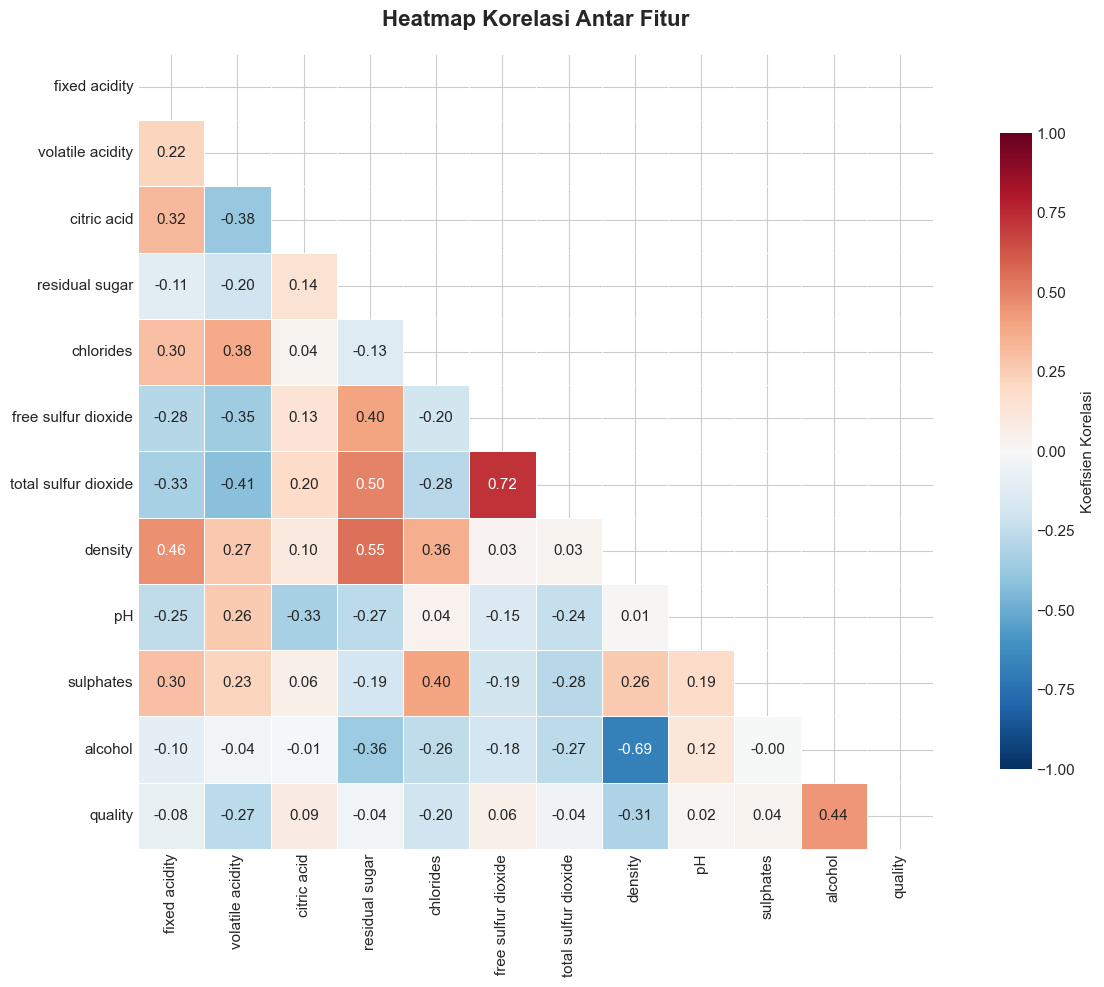


KORELASI FITUR DENGAN TARGET (quality)
alcohol                 0.444319
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64


In [12]:
# Heatmap korelasi antar fitur numerik
fig, ax = plt.subplots(figsize=(14, 10))

correlation_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Koefisien Korelasi'},
            ax=ax, vmin=-1, vmax=1)

ax.set_title('Heatmap Korelasi Antar Fitur', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

# Menampilkan korelasi tertinggi dengan target (quality)
print("\n" + "=" * 60)
print("KORELASI FITUR DENGAN TARGET (quality)")
print("=" * 60)
quality_corr = correlation_matrix['quality'].drop('quality').sort_values(ascending=False)
print(quality_corr)

### 4.4 Analisis Keseimbangan Kelas Target

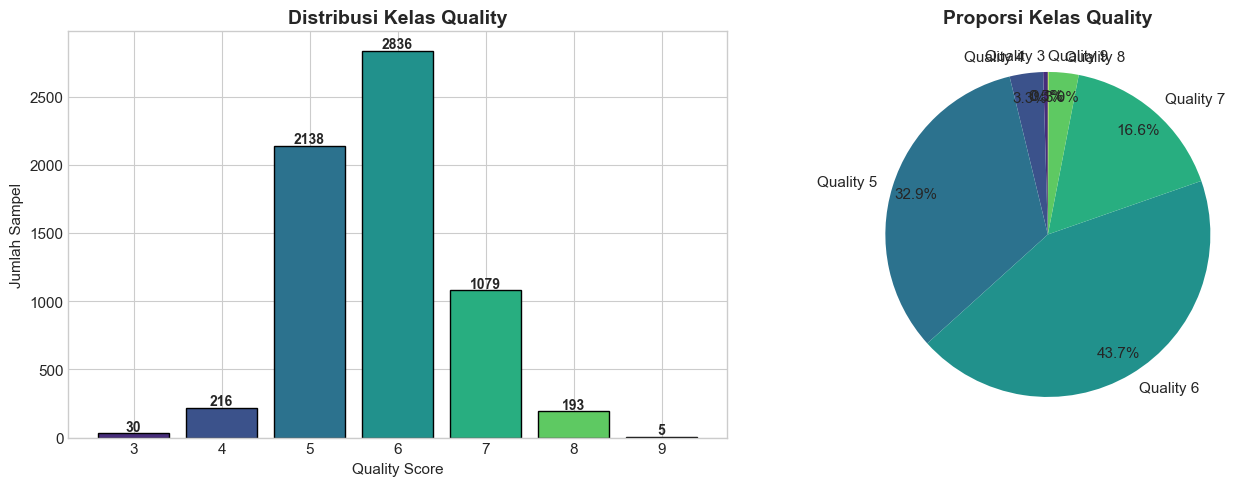


Distribusi kelas quality:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

Jumlah kelas unik: 7


In [13]:
# Distribusi kelas target (quality)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
quality_counts = df['quality'].value_counts().sort_index()
colors = sns.color_palette('viridis', len(quality_counts))
axes[0].bar(quality_counts.index, quality_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribusi Kelas Quality', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Jumlah Sampel')

for i, (q, c) in enumerate(zip(quality_counts.index, quality_counts.values)):
    axes[0].text(q, c + 20, str(c), ha='center', fontweight='bold', fontsize=10)

# Pie chart
axes[1].pie(quality_counts.values, labels=[f'Quality {q}' for q in quality_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90, pctdistance=0.85)
axes[1].set_title('Proporsi Kelas Quality', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_kelas_target.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDistribusi kelas quality:")
print(quality_counts)
print(f"\nJumlah kelas unik: {df['quality'].nunique()}")

In [14]:
# Distribusi wine type
print("=" * 40)
print("DISTRIBUSI WINE TYPE")
print("=" * 40)
print(df['wine_type'].value_counts())
print(f"\nProporsi: ")
print((df['wine_type'].value_counts() / len(df) * 100).round(2).astype(str) + '%')

DISTRIBUSI WINE TYPE
wine_type
white    4898
red      1599
Name: count, dtype: int64

Proporsi: 
wine_type
white    75.39%
red      24.61%
Name: count, dtype: object


### 4.5 Deteksi Outlier

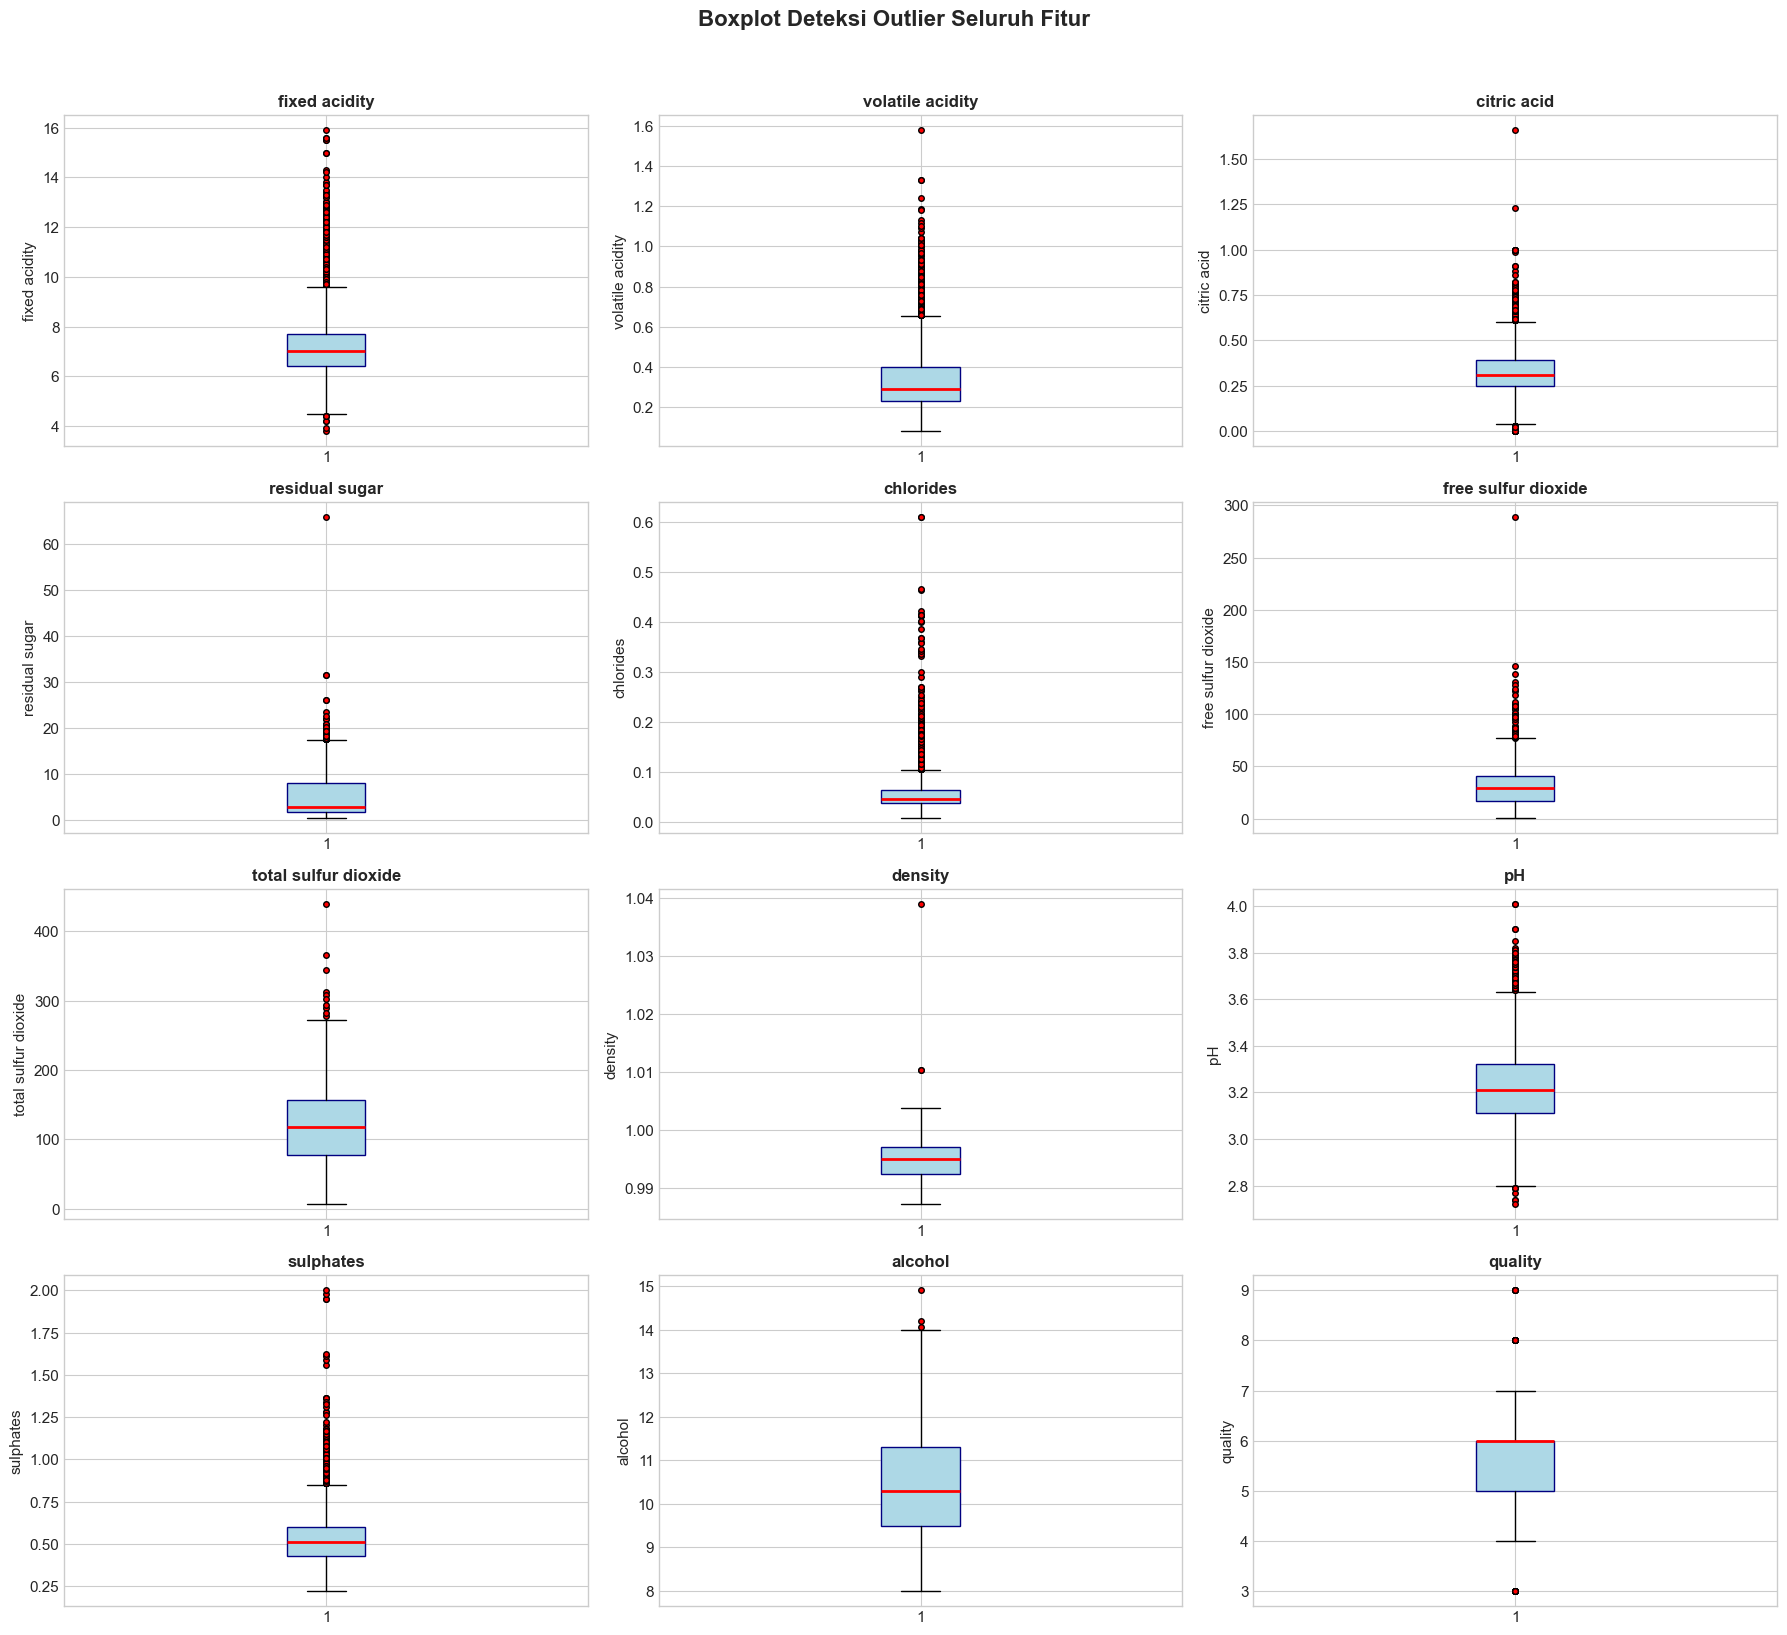


JUMLAH OUTLIER PER FITUR (IQR Method)
fixed acidity                 :   357 outlier (5.49%)
volatile acidity              :   377 outlier (5.80%)
citric acid                   :   509 outlier (7.83%)
residual sugar                :   118 outlier (1.82%)
chlorides                     :   286 outlier (4.40%)
free sulfur dioxide           :    62 outlier (0.95%)
total sulfur dioxide          :    10 outlier (0.15%)
density                       :     3 outlier (0.05%)
pH                            :    73 outlier (1.12%)
sulphates                     :   191 outlier (2.94%)
alcohol                       :     3 outlier (0.05%)
quality                       :   228 outlier (3.51%)


In [15]:
# Boxplot untuk mendeteksi outlier pada seluruh fitur numerik
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))
fig.suptitle('Boxplot Deteksi Outlier Seluruh Fitur', fontsize=16, fontweight='bold', y=1.02)

for idx, col in enumerate(numeric_cols):
    row = idx // 3
    col_idx = idx % 3
    ax = axes[row][col_idx]
    
    bp = ax.boxplot(df[col].dropna(), patch_artist=True, 
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig('boxplot_outlier.png', dpi=150, bbox_inches='tight')
plt.show()

# Menghitung jumlah outlier per fitur menggunakan IQR method
print("\n" + "=" * 60)
print("JUMLAH OUTLIER PER FITUR (IQR Method)")
print("=" * 60)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"{col:30s}: {outliers:5d} outlier ({(outliers/len(df)*100):.2f}%)")

### 4.6 Pairplot Fitur Terpilih

Fitur dengan korelasi tertinggi terhadap quality: ['alcohol', 'density', 'volatile acidity', 'chlorides']


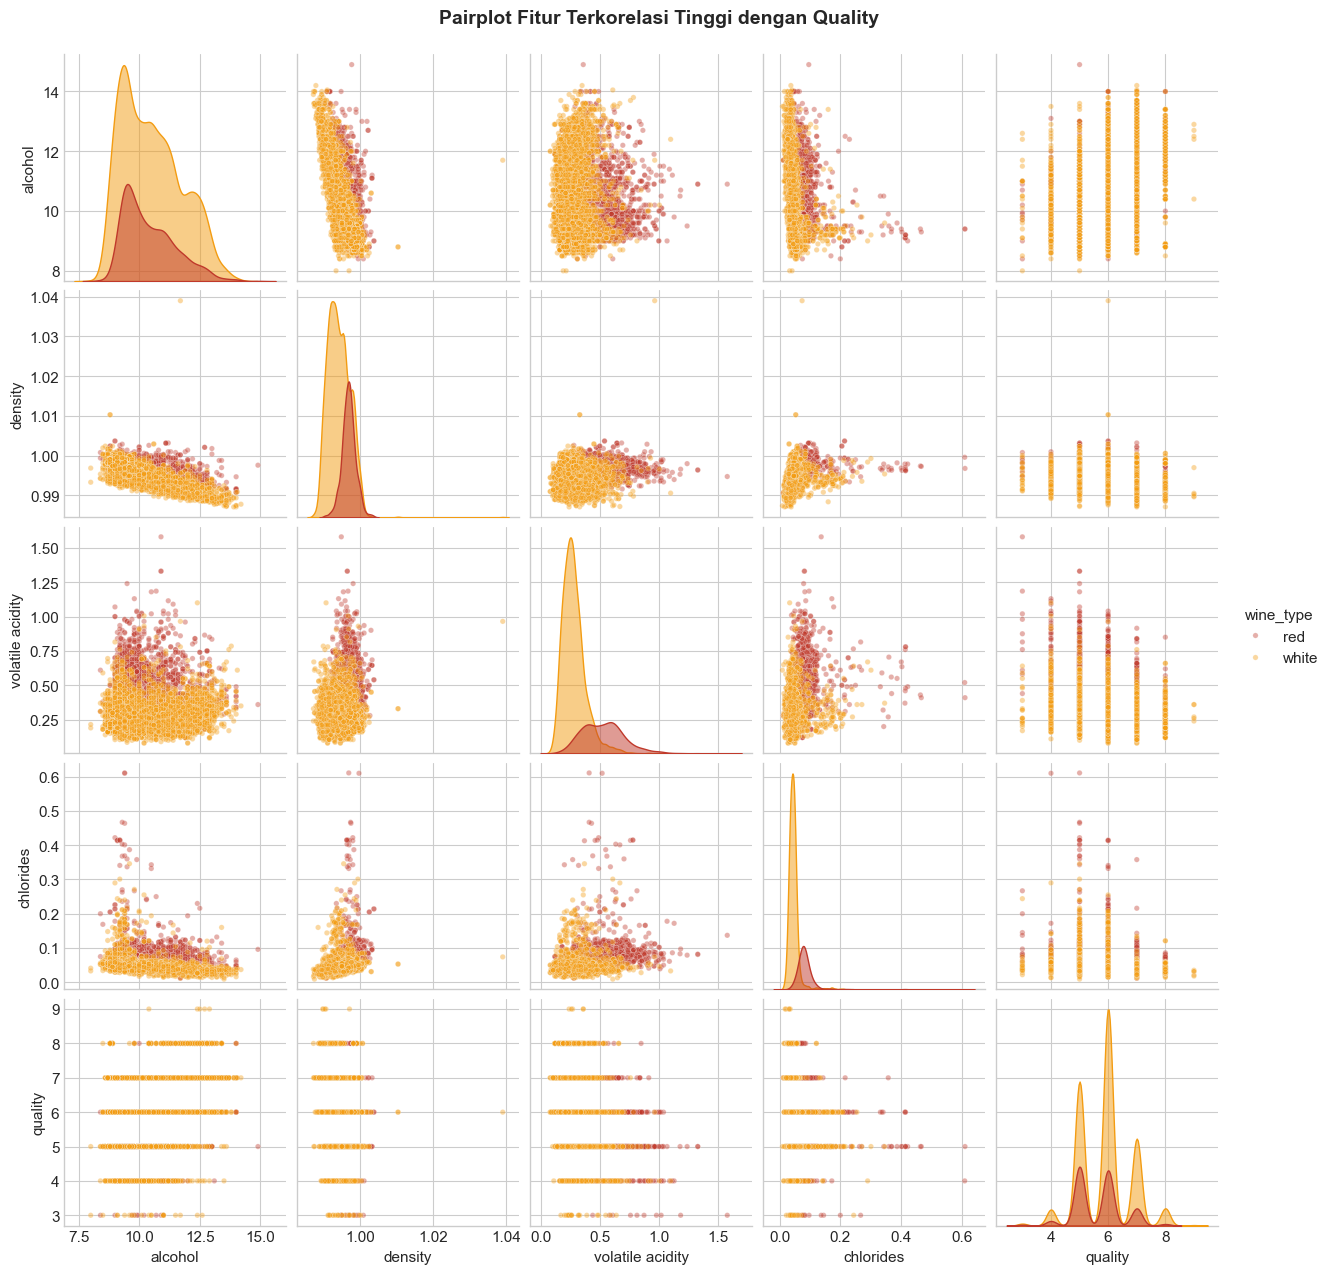

In [16]:
# Pairplot untuk fitur dengan korelasi tertinggi terhadap quality
top_features = quality_corr.abs().sort_values(ascending=False).head(4).index.tolist()
top_features.append('quality')

print(f"Fitur dengan korelasi tertinggi terhadap quality: {top_features[:-1]}")

g = sns.pairplot(df[top_features + ['wine_type']], hue='wine_type',
                 palette={'red': '#C0392B', 'white': '#F39C12'},
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kws={'alpha': 0.5})
g.figure.suptitle('Pairplot Fitur Terkorelasi Tinggi dengan Quality', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot_fitur_terkorelasi.png', dpi=150, bbox_inches='tight')
plt.show()

### Kesimpulan EDA

Berdasarkan hasil eksplorasi data, berikut temuan utama:

1. **Missing Values**: Tidak terdapat missing values pada dataset
2. **Duplikat**: Terdapat beberapa baris duplikat yang perlu diperhatikan
3. **Distribusi Target**: Kelas target (quality) tidak seimbang, mayoritas berada di kelas 5 dan 6
4. **Outlier**: Beberapa fitur memiliki outlier yang signifikan (residual sugar, chlorides, sulphates)
5. **Korelasi**: Alkohol memiliki korelasi positif tertinggi dengan quality, sedangkan volatile acidity memiliki korelasi negatif
6. **Wine Type**: Distribusi antara red wine dan white wine tidak seimbang (lebih banyak white wine)

Temuan ini akan menjadi dasar untuk langkah preprocessing selanjutnya.

## 5. Data Preprocessing

Berdasarkan hasil EDA, langkah-langkah preprocessing yang akan dilakukan:
1. Menghapus data duplikat
2. Menangani outlier menggunakan metode IQR capping
3. Encoding kolom kategorikal (wine_type)
4. Membuat kategori kualitas wine (binning)
5. Normalisasi/standarisasi fitur
6. Membagi data menjadi train dan test set

### 5.1 Menghapus Data Duplikat

In [17]:
# Menghapus data duplikat
print(f"Jumlah data sebelum menghapus duplikat: {len(df)}")
df_clean = df.drop_duplicates()
print(f"Jumlah data setelah menghapus duplikat: {len(df_clean)}")
print(f"Data yang dihapus: {len(df) - len(df_clean)} baris")

Jumlah data sebelum menghapus duplikat: 6497
Jumlah data setelah menghapus duplikat: 5320
Data yang dihapus: 1177 baris


### 5.2 Penanganan Outlier (IQR Capping)

In [18]:
# Menangani outlier menggunakan IQR capping (winsorization)
# Fitur yang memiliki outlier signifikan akan di-cap pada batas IQR
feature_cols = [col for col in numeric_cols if col != 'quality']

df_processed = df_clean.copy()

print("=" * 60)
print("PENANGANAN OUTLIER - IQR CAPPING")
print("=" * 60)

for col in feature_cols:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_count_before = ((df_processed[col] < lower) | (df_processed[col] > upper)).sum()
    
    df_processed[col] = df_processed[col].clip(lower=lower, upper=upper)
    
    outlier_count_after = ((df_processed[col] < lower) | (df_processed[col] > upper)).sum()
    
    if outlier_count_before > 0:
        print(f"{col:30s}: {outlier_count_before} outlier di-cap")

print("\nOutlier capping selesai.")

PENANGANAN OUTLIER - IQR CAPPING
fixed acidity                 : 304 outlier di-cap
volatile acidity              : 279 outlier di-cap
citric acid                   : 143 outlier di-cap
residual sugar                : 141 outlier di-cap
chlorides                     : 237 outlier di-cap
free sulfur dioxide           : 44 outlier di-cap
total sulfur dioxide          : 10 outlier di-cap
density                       : 3 outlier di-cap
pH                            : 49 outlier di-cap
sulphates                     : 163 outlier di-cap
alcohol                       : 1 outlier di-cap

Outlier capping selesai.


### 5.3 Encoding Data Kategorikal

In [19]:
# Label encoding untuk kolom wine_type
le = LabelEncoder()
df_processed['wine_type_encoded'] = le.fit_transform(df_processed['wine_type'])

print("Label Encoding wine_type:")
print(f"  red   -> {le.transform(['red'])[0]}")
print(f"  white -> {le.transform(['white'])[0]}")

# Menghapus kolom wine_type string asli
df_processed = df_processed.drop('wine_type', axis=1)

print(f"\nShape dataset setelah encoding: {df_processed.shape}")
df_processed.head()

Label Encoding wine_type:
  red   -> 0
  white -> 1

Shape dataset setelah encoding: (5320, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type_encoded
0,7.40,0.68,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.80,0.68,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.80,0.68,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,9.65,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
5,7.40,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


### 5.4 Binning Kelas Quality

Mapping quality ke kategori:
  0 (Low)    : quality 3-4
  1 (Medium) : quality 5-6
  2 (High)   : quality 7-9

Distribusi kategori:
quality_category
0     236
1    4075
2    1009
Name: count, dtype: int64


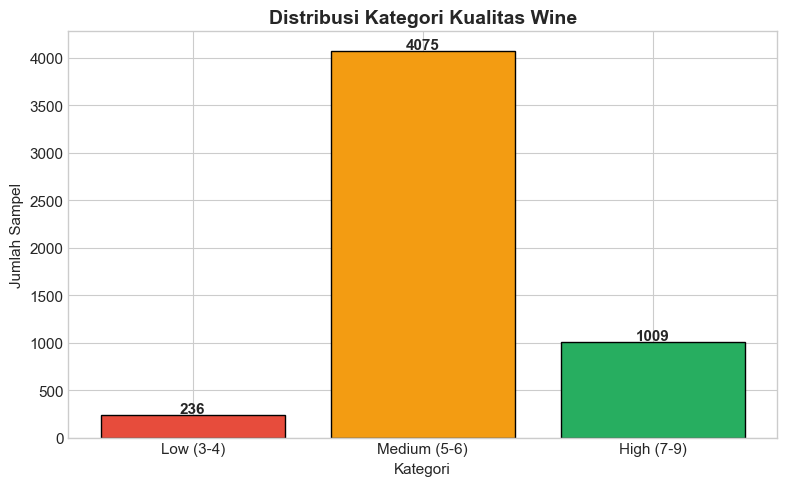

In [20]:
# Membuat kategori kualitas wine untuk klasifikasi:
# - Rendah (Low): quality 3-4
# - Sedang (Medium): quality 5-6  
# - Tinggi (High): quality 7-9

def categorize_quality(quality):
    if quality <= 4:
        return 0  # Low
    elif quality <= 6:
        return 1  # Medium
    else:
        return 2  # High

df_processed['quality_category'] = df_processed['quality'].apply(categorize_quality)

print("Mapping quality ke kategori:")
print("  0 (Low)    : quality 3-4")
print("  1 (Medium) : quality 5-6")
print("  2 (High)   : quality 7-9")
print(f"\nDistribusi kategori:")
print(df_processed['quality_category'].value_counts().sort_index())

# Visualisasi distribusi kategori baru
fig, ax = plt.subplots(figsize=(8, 5))
category_labels = ['Low (3-4)', 'Medium (5-6)', 'High (7-9)']
category_counts = df_processed['quality_category'].value_counts().sort_index()
colors_cat = ['#E74C3C', '#F39C12', '#27AE60']
ax.bar(category_labels, category_counts.values, color=colors_cat, edgecolor='black')
ax.set_title('Distribusi Kategori Kualitas Wine', fontsize=14, fontweight='bold')
ax.set_xlabel('Kategori')
ax.set_ylabel('Jumlah Sampel')

for i, v in enumerate(category_counts.values):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_kategori.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Pemisahan Fitur dan Target

In [21]:
# Memisahkan fitur (X) dan target (y)
# Menggunakan quality_category sebagai target klasifikasi
X = df_processed.drop(['quality', 'quality_category'], axis=1)
y = df_processed['quality_category']

print(f"Shape fitur (X): {X.shape}")
print(f"Shape target (y): {y.shape}")
print(f"\nFitur yang digunakan:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")
print(f"\nDistribusi target:")
print(y.value_counts().sort_index())

Shape fitur (X): (5320, 12)
Shape target (y): (5320,)

Fitur yang digunakan:
  1. fixed acidity
  2. volatile acidity
  3. citric acid
  4. residual sugar
  5. chlorides
  6. free sulfur dioxide
  7. total sulfur dioxide
  8. density
  9. pH
  10. sulphates
  11. alcohol
  12. wine_type_encoded

Distribusi target:
quality_category
0     236
1    4075
2    1009
Name: count, dtype: int64


### 5.6 Standarisasi Fitur

In [22]:
# Standarisasi fitur menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("Statistik fitur setelah standarisasi:")
print(X_scaled.describe().round(3).T[['mean', 'std', 'min', 'max']])

Statistik fitur setelah standarisasi:
                      mean  std    min    max
fixed acidity         -0.0  1.0 -2.469  2.303
volatile acidity       0.0  1.0 -1.729  2.299
citric acid           -0.0  1.0 -2.273  2.333
residual sugar        -0.0  1.0 -1.029  2.598
chlorides             -0.0  1.0 -2.031  2.476
free sulfur dioxide    0.0  1.0 -1.705  2.875
total sulfur dioxide   0.0  1.0 -1.914  2.802
density                0.0  1.0 -2.558  3.138
pH                     0.0  1.0 -2.813  2.763
sulphates             -0.0  1.0 -2.354  2.492
alcohol               -0.0  1.0 -2.150  3.122
wine_type_encoded     -0.0  1.0 -1.707  0.586


### 5.7 Pembagian Data Train-Test

In [23]:
# Membagi data menjadi training set (80%) dan test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Menjaga proporsi kelas
)

print("=" * 60)
print("HASIL PEMBAGIAN DATA")
print("=" * 60)
print(f"Training set : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set     : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nDistribusi target pada training set:")
print(y_train.value_counts().sort_index())
print(f"\nDistribusi target pada test set:")
print(y_test.value_counts().sort_index())

HASIL PEMBAGIAN DATA
Training set : 4256 sampel (80.0%)
Test set     : 1064 sampel (20.0%)

Distribusi target pada training set:
quality_category
0     189
1    3260
2     807
Name: count, dtype: int64

Distribusi target pada test set:
quality_category
0     47
1    815
2    202
Name: count, dtype: int64


### 5.8 Menyimpan Data Preprocessing

In [24]:
# Menyimpan dataset yang sudah dipreproses
# Gabungkan X_scaled dan y untuk disimpan sebagai satu file
df_final = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)

# Simpan ke folder preprocessing
output_path = 'wine_quality_preprocessing.csv'
df_final.to_csv(output_path, index=False)

print(f"Dataset preprocessing berhasil disimpan ke: {output_path}")
print(f"Shape: {df_final.shape}")
print(f"Kolom: {list(df_final.columns)}")

# Simpan juga data train dan test secara terpisah
train_data = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
test_data = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

train_data.to_csv('wine_quality_train.csv', index=False)
test_data.to_csv('wine_quality_test.csv', index=False)

print(f"\nTraining data disimpan: wine_quality_train.csv ({train_data.shape})")
print(f"Test data disimpan: wine_quality_test.csv ({test_data.shape})")
print("\n=== PREPROCESSING SELESAI ===")

Dataset preprocessing berhasil disimpan ke: wine_quality_preprocessing.csv
Shape: (6249, 13)
Kolom: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'wine_type_encoded', 'quality_category']



Training data disimpan: wine_quality_train.csv ((4256, 13))
Test data disimpan: wine_quality_test.csv ((1064, 13))

=== PREPROCESSING SELESAI ===


---

## Rangkuman Preprocessing

| Tahap | Deskripsi | Hasil |
|---|---|---|
| Penghapusan Duplikat | Menghapus baris duplikat | Data bersih dari duplikat |
| Penanganan Outlier | IQR Capping pada fitur numerik | Outlier di-cap pada batas IQR |
| Encoding | Label Encoding pada wine_type | red=0, white=1 |
| Binning | Mengubah quality menjadi 3 kategori | Low(0), Medium(1), High(2) |
| Standarisasi | StandardScaler pada seluruh fitur | Mean~0, Std~1 |
| Train-Test Split | 80% train, 20% test (stratified) | Data siap dilatih |

Dataset yang telah dipreproses siap digunakan untuk pelatihan model pada tahap selanjutnya.